In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import tapas.datasets
import tapas.generators
import tapas.threat_models
import tapas.attacks
import tapas.report
from tapas.datasets.canary import create_canary
from sklearn.metrics import roc_auc_score
from utils.plotting import double_plot
from utils.my_attack import MyAttack
from utils.my_feature import MyFeature
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import random

from tapas.generators.generator import ReprosynGenerator
from reprosyn.methods import DS_PRIVBAYES
from tapas.attacks.set_classifiers import RandomTargetedQueryFeature
from tools.tapas.tapas_data_processors import AdultDataProcessor
from tools.baseline_attack import get_baseline_score


In [2]:
def _sample_shadow_dataset(shadow_dataset_pool: list[tapas.datasets.dataset.TabularDataset], number_of_shadow_models: int):
   """_summary_
   Args:
       shadow_dataset_pool (_type_): _description_
       number_of_shadow_models (int): _description_

   Returns:
       list[tapas.datasets.dataset.TabularDataset, bool]: subset of shadow_dataset_pool of lenght number_of_shadow_models such that there is the same number of dataset with/without target.
   """

   assert number_of_shadow_models % 2 == 0, 'number_of_shadow_models should be a even integer'
   shadow_datasets = random.sample(shadow_dataset_pool[0], int(number_of_shadow_models / 2))
   shadow_datasets.extend(random.sample(shadow_dataset_pool[1], int(number_of_shadow_models / 2)))
   return shadow_datasets

# _sample_shadow_dataset(shadow_datasets, 6)

In [8]:
######## ATTACK INPUT#############
data = tapas.datasets.TabularDataset.read("../data/adult")
data = AdultDataProcessor.process_tapas_tabulardataset(data)
#data = data.sample(frac = 0.1)  #downsample the data 

ind = [int(random.random() * len(data.data))]
target_record = data.get_records(ind)
data.drop_records(ind, in_place=True)
#data, target_record = create_canary(data)

# our original version
attacker_data, defender_data = data.create_subsets(n = 2, sample_size= int(len(data) / 2))

# to have datasets the same size as master thesis 
aux_data_size = 10000
test_data_size = 5000
real_datasets_size = 1000


data_sub = data.sample(n_samples=aux_data_size + test_data_size)  
attacker_data = data_sub.create_subsets(n=1, sample_size= aux_data_size)[0]
defender_data = data_sub.create_subsets(n=1, sample_size= test_data_size)[0]



######## GENERATOR #############
generator = ReprosynGenerator(DS_PRIVBAYES, label="PrivBayes", epsilon=1.0)

# generator like in master thesis: (much slower)
#generator = ReprosynGenerator(DS_PRIVBAYES, label="PrivBayes", epsilon=1.0, histogram_bins = 18,degree = 3)

#generator = tapas.generators.Raw()


######## DEFINE ATTACKER KNOLEDGE ############

#number of data points in synthetic dataset
i = int(len(defender_data) / 5)

# master thesis version 
i = 1000

data_knowledge = tapas.threat_models.AuxiliaryDataKnowledge(
      test_data= defender_data,
      aux_data= attacker_data,
      num_training_records= i
)

sdg_knowledge = tapas.threat_models.BlackBoxKnowledge(
    generator,
    num_synthetic_records = i,
)
print(len(data.data))

45221


In [9]:
target_record.data

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
37119,21,Private,315470.0,HS-grad,9,Never-married,Sales,Own-child,White,Female,0.0,0.0,30.0,United-States,<=50K


In [10]:
attacker_data.data

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
47904,68,Local-gov,254218.0,Assoc-voc,11,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,24.0,United-States,<=50K
37754,71,Private,148003.0,Bachelors,13,Divorced,Sales,Not-in-family,White,Female,0.0,1911.0,38.0,United-States,>50K
41019,58,Private,66788.0,HS-grad,9,Separated,Machine-op-inspct,Unmarried,White,Male,0.0,0.0,40.0,Portugal,<=50K
6043,25,Private,144478.0,Some-college,10,Never-married,Other-service,Own-child,White,Male,0.0,0.0,40.0,Poland,<=50K
4841,68,Federal-gov,232151.0,Some-college,10,Divorced,Adm-clerical,Other-relative,Black,Female,2346.0,0.0,40.0,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18617,25,Private,193773.0,HS-grad,9,Never-married,Other-service,Not-in-family,Black,Female,0.0,0.0,35.0,United-States,<=50K
19547,23,Private,214542.0,Some-college,10,Never-married,Farming-fishing,Own-child,White,Male,0.0,0.0,40.0,United-States,<=50K
19430,19,Private,445728.0,HS-grad,9,Never-married,Craft-repair,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
48119,29,Private,163167.0,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0.0,0.0,55.0,United-States,>50K


In [11]:
defender_data.data

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
14048,47,Private,169549.0,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0.0,0.0,40.0,United-States,>50K
17804,44,Private,325461.0,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,1902.0,50.0,United-States,>50K
5410,21,Private,146499.0,Assoc-voc,11,Married-civ-spouse,Adm-clerical,Other-relative,White,Female,0.0,1579.0,40.0,United-States,<=50K
2396,53,Private,156843.0,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,0.0,1564.0,54.0,United-States,>50K
41774,57,Private,477867.0,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0.0,0.0,40.0,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36455,63,Self-emp-not-inc,74991.0,HS-grad,9,Widowed,Farming-fishing,Unmarried,White,Male,0.0,0.0,60.0,United-States,<=50K
20035,65,Self-emp-not-inc,144822.0,9th,5,Married-civ-spouse,Craft-repair,Husband,White,Male,0.0,0.0,45.0,United-States,<=50K
47829,37,Private,53232.0,Prof-school,15,Never-married,Prof-specialty,Not-in-family,Asian-Pac-Islander,Female,0.0,0.0,55.0,United-States,>50K
39734,39,Self-emp-not-inc,33001.0,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0.0,0.0,40.0,United-States,<=50K


In [12]:
#Baseline attack 
baseline_score = get_baseline_score(attacker_data, target_record, num_bins = 100, approx=True)
baseline_score

estimating categorical probs
estimating approx kdes(histogram)


[0.6099]

In [13]:
'''
from tapas.attacks.set_classifiers import NaiveSetFeature

f = NaiveSetFeature()
threat_model = tapas.threat_models.TargetedMIA(
            attacker_knowledge_data=data_knowledge,
            target_record=target_record,
            attacker_knowledge_generator=sdg_knowledge,
            generate_pairs=True,
            replace_target=True
         )

test_datasets, truth_labels = threat_model._generate_samples(2, True, True)
print(truth_labels)
f(test_datasets)
'''

'\nfrom tapas.attacks.set_classifiers import NaiveSetFeature\n\nf = NaiveSetFeature()\nthreat_model = tapas.threat_models.TargetedMIA(\n            attacker_knowledge_data=data_knowledge,\n            target_record=target_record,\n            attacker_knowledge_generator=sdg_knowledge,\n            generate_pairs=True,\n            replace_target=True\n         )\n\ntest_datasets, truth_labels = threat_model._generate_samples(2, True, True)\nprint(truth_labels)\nf(test_datasets)\n'

In [14]:
def Fast_MIA_attack(complexity_range: list[int], run_per_range: int, number_of_tests: int):
   threat_model = tapas.threat_models.TargetedMIA(
            attacker_knowledge_data=data_knowledge,
            target_record=target_record,
            attacker_knowledge_generator=sdg_knowledge,
            generate_pairs=True,
            replace_target=True,
         )
   number_of_generated_shadow_datasets = complexity_range[-1]*2
   shadow_datasets, shadow_labels = threat_model.generate_training_samples(number_of_generated_shadow_datasets, ignore_memory=True)
   shadow_data = list(zip(shadow_datasets, shadow_labels))
   shadow_data_0 = [sd for sd in shadow_data if not sd[1]]
   shadow_data_1 = [sd for sd in shadow_data if sd[1]]
   shadow_data_pool = [shadow_data_0, shadow_data_1]
   test_datasets, truth_labels = threat_model._generate_samples(number_of_tests, training = False, ignore_memory = True)
   M_0 = []
   S_0 = []
   M_1 = []
   S_1 = []
   for complexity in complexity_range:
      print('COMPLEXITY: ', complexity)
      P_0 = []
      P_1 = []
      for _ in range(run_per_range):
         sampled_shadow_data = _sample_shadow_dataset(shadow_data_pool, complexity)
         random.shuffle(sampled_shadow_data)
         sampled_datasets = [dataset[0] for dataset in sampled_shadow_data]
         sampled_labels = [dataset[1] for dataset in sampled_shadow_data]

         # attacker = tapas.attacks.ProbabilityEstimationAttack(KernelDensity(), criterion="accuracy", label="KernelEstimator")
         # attacker.train(threat_model, num_samples=complexity)

         attacker = MyAttack(n_estimators=100, features=RandomTargetedQueryFeature(target_record,4,10), use_corr=False, use_hist=False)
         attacker.classifier.fit(sampled_datasets, sampled_labels)
         attacker.trained = True
            
         
         # to investigate train accuracy   
         train_pred_labels = attacker.attack(sampled_datasets)
         from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
         accuracy = accuracy_score(sampled_labels, train_pred_labels)
         precision = precision_score(sampled_labels, train_pred_labels)
         recall = recall_score(sampled_labels, train_pred_labels)
         f1 = f1_score(sampled_labels, train_pred_labels)

         print("Performance on training data:")
         print(sampled_labels, train_pred_labels)
         print(f"Accuracy:  {accuracy:.4f}")
         print(f"Precision: {precision:.4f}")
         print(f"Recall:    {recall:.4f}")
         print(f"F1 Score:  {f1:.4f}")   
         
         # prediction on test
         pred_labels = attacker.attack(test_datasets)
         P_0.extend([p for i, p in enumerate(pred_labels) if truth_labels[i] == False])
         P_1.extend([p for i, p in enumerate(pred_labels) if truth_labels[i] == True])
         # print('AuROC :', roc_auc_score(truth_labels, attacker.attack_score(test_datasets)))
            
      print(P_0, P_1)
      M_0.append(np.mean(P_0))
      S_0.append(np.std(P_0))
      M_1.append(np.mean(P_1))
      S_1.append(np.std(P_1))
   return M_0, S_0, M_1, S_1



COMPLEXITY:  2
Performance on training data:
[False, True] [False  True]
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
Performance on training data:
[False, True] [False  True]
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
Performance on training data:
[False, True] [False  True]
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
Performance on training data:
[False, True] [False  True]
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
Performance on training data:
[True, False] [ True False]
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
Performance on training data:
[True, False] [ True False]
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
Performance on training data:
[True, False] [ True False]
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
Performance on training data:
[True, False] [ True False]
Accuracy:  1.0000

Performance on training data:
[False, False, True, True, False, True, False, True, False, True, True, False, True, True, True, False, False, False, False, True] [False False  True  True False  True False  True False  True  True False
  True  True  True False False False False  True]
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
Performance on training data:
[False, True, True, False, False, True, False, False, False, True, True, True, False, False, False, True, True, True, False, True] [False False  True False  True  True False  True False  True  True  True
 False  True  True False  True False False  True]
Accuracy:  0.6500
Precision: 0.6364
Recall:    0.7000
F1 Score:  0.6667
[True, True, False, True, False, False, True, True, False, False] [False, True, False, True, True, False, False, True, False, True]


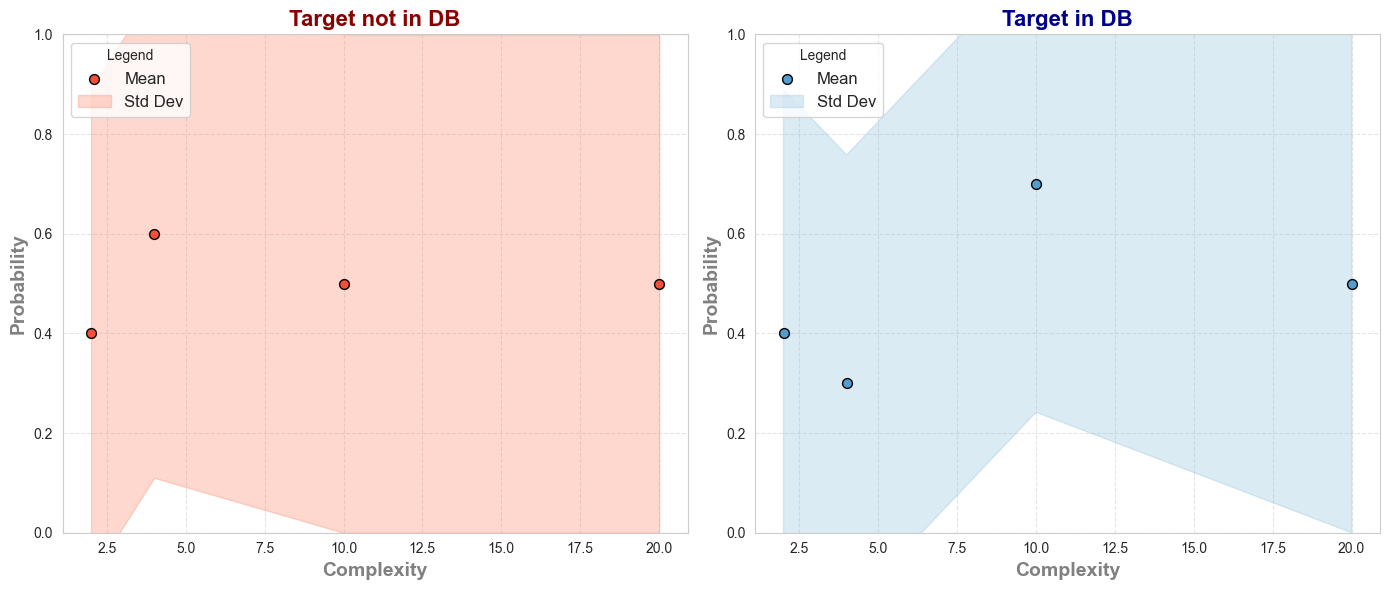

CPU times: user 1min 37s, sys: 1.16 s, total: 1min 38s
Wall time: 1min 41s


In [15]:
%%time
COMPLEXITY_RANGE = [2,4,10,20]
RUN_PER_RANGE = 10
TESTS_PER_RANGE = 2
M_0, S_0, M_1, S_1 = Fast_MIA_attack(COMPLEXITY_RANGE, RUN_PER_RANGE, TESTS_PER_RANGE)
double_plot(np.array(COMPLEXITY_RANGE), np.array(M_0), np.array(S_0), np.array(M_1), np.array(S_1))